##### Import statements:

In [2]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [3]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'delta_ps_v_ps_entangler'

##### Load previously-saved results:

In [4]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 
loss_df = tngl_evo_pred_results['ae_df']

##### Compute prediction model $\Delta \text{PS}_{\text{prediction}_i} = \text{PS}(h^{\text{final}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)) - \text{PS}(h^{\text{random}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))$ for each model realization: 

In [5]:
# Select results for prediction model hidden layer:
geo_df_pred = geo_df[geo_df.mdl_type=='prediction']
geo_df_pred_hidden = geo_df_pred[geo_df_pred.layer=='hidden']

# Get first epoch results:
geo_df_pred_hidden_e0 = geo_df_pred_hidden[geo_df_pred_hidden.epoch==0]
geo_df_pred_hidden_e0 = geo_df_pred_hidden_e0.rename(columns={'parallelism':'parallelism_e0'}) 

# Get final epoch results:
max_epoch_df = geo_df_pred_hidden[['pred_mdl_id', 'epoch']].groupby('pred_mdl_id').max().reset_index()
geo_df_pred_hidden_efinal = pd.merge(geo_df_pred_hidden, max_epoch_df, on=['pred_mdl_id', 'epoch'])
geo_df_pred_hidden_efinal = geo_df_pred_hidden_efinal.rename(columns={'parallelism':'parallelism_efinal'}) 

# Merge on model id:
ps_history_df = pd.merge(geo_df_pred_hidden_e0[['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds', 'parallelism_e0']],\
      geo_df_pred_hidden_efinal[['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds','parallelism_efinal']],\
      on=['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds'])

# Compute mean initial and final hidden-layer PS for each model:
delta_df = ps_history_df.groupby(['pred_mdl_id', 'dichotomy_idx']).mean()\
    .groupby('pred_mdl_id').mean().reset_index()

# Compute delta PS:
delta_df['delta_parallelism'] = delta_df.parallelism_efinal - delta_df.parallelism_e0

##### Compute PS for entangled input to each model realization, i.e., $\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$:

In [17]:
geo_df_pred_inpt = geo_df_pred[geo_df_pred.layer=='inpt']
geo_df_pred_inpt_e0 = geo_df_pred_inpt[geo_df_pred.epoch==0] # Shouldn't be necessary, but including just in case

# Compute mean PS for entangled input to each model:
inpt_df = geo_df_pred_inpt_e0[['pred_mdl_id', 'dichotomy_idx', 'parallelism']]\
    .groupby(['pred_mdl_id', 'dichotomy_idx']).mean()\
    .groupby('pred_mdl_id').mean().reset_index()
inpt_df = inpt_df.rename(columns={'parallelism':'parallelism_tngl_inpt'})

# Merge with delta PS results:
scatter_df = pd.merge(delta_df, inpt_df, on='pred_mdl_id')

##### Scatter $\Delta \text{PS}_{\text{prediction}_i}$ vs $\text{PS}\left(h_{\text{entangler}}(\mathbf{X}_i)\right)$:

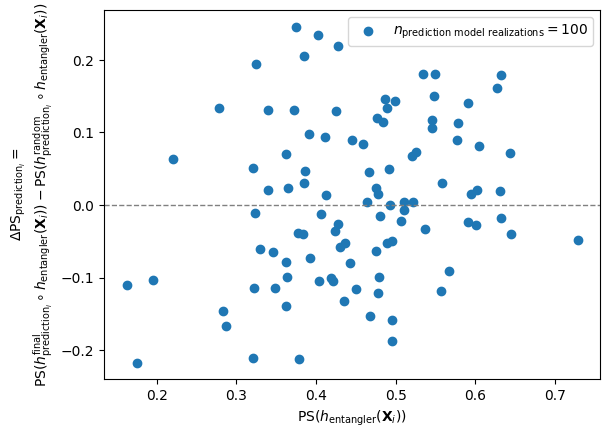

In [29]:
scatter_fig, scatter_ax = plt.subplots()

# Scatter:
leg_text = r'$n_{{\text{{prediction model realizations}}}} = {}$'.format(scatter_df.shape[0])
plt.scatter(scatter_df.parallelism_tngl_inpt, scatter_df.delta_parallelism, label=leg_text)

# Add axis labels:
xlabel = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$'
ylabel0 = r'$\Delta \text{PS}_{\text{prediction}_i} = $'
ylabel1 = r'$\text{PS}(h^{\text{final}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)) - \text{PS}(h^{\text{random}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))$'
ylabel = '\n'.join([ylabel0, ylabel1])
plt.xlabel(xlabel)
plt.ylabel(ylabel)

# Add y=0 reference line:
plt.axhline(0, color='gray', linewidth=1, linestyle='--')

# Add legend:
plt.legend()

##### Save output:

In [ ]:
if save_output:

    # Create output directory:
    input_dir = os.path.split(input_path)[0]
    base_dir_name = 'scatter_delta_ps_v_ps_tngl_inpt'
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(scatter_fig)
    file_basename = base_dir_name
    ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(ps_png_path)
    ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(ps_svg_path)
    
    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(ps_png_path)
    M.add_output(ps_svg_path)
    metadata_path = os.path.join(curr_output_directory, file_basename + '.json')
    write_metadata(M, metadata_path)